In [1]:
import sys
sys.path.remove('/user/home/ef17148/.local/lib/python3.12/site-packages')


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import matplotlib.colors as mcolors

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadBaseSatelliteData

In [3]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
from vis_plotting.fp_plotting import *

### Data loading

In [10]:
fp_datadir = "/group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/GOSAT-BRAZIL-column_SOUTHAMERICA_2016*.nc"

In [5]:
"""
Load the footprints for the region and period with the base data object.
Stores the footprints (without cropping) in data.fp_data_full
load_everything=True also loads the original meteorology, without cropping or interpolating, in data.met_file, as well as the topography and landuse in data.topog_file and data.landcover_file, which are interpolated in space to the shape of the footprints
"""
data = LoadBaseSatelliteData(2016, region="BRAZIL", load_everything=True, verbose=True)

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
no sampling was done because you didnt pass a valid sampling mode, or freq=1
Loading 21671 footprints

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
---- All done!


## Plotting meteorology

## Plotting footprints

In [25]:
from model.data.load_data import LoadSquareSatelliteData

data = LoadSquareSatelliteData(2016, freq=10, size=50, region="BRAZIL", load_everything=True, verbose=True, load_fps_as="both")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
reduced the number of datapoints by frequency 10
Loading 2168 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the longitude dimension to extract size 50 (0 and 2 idxs on either side) Padding with nan
35 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 1.61% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 0, 'S': 0, 'E': 35, 'W': 0}

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc
----- Cutting met


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockw

calculated wind angle and/or speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


### ghost plot

0 JFM
1 AMJ
2 JAS
3 OND


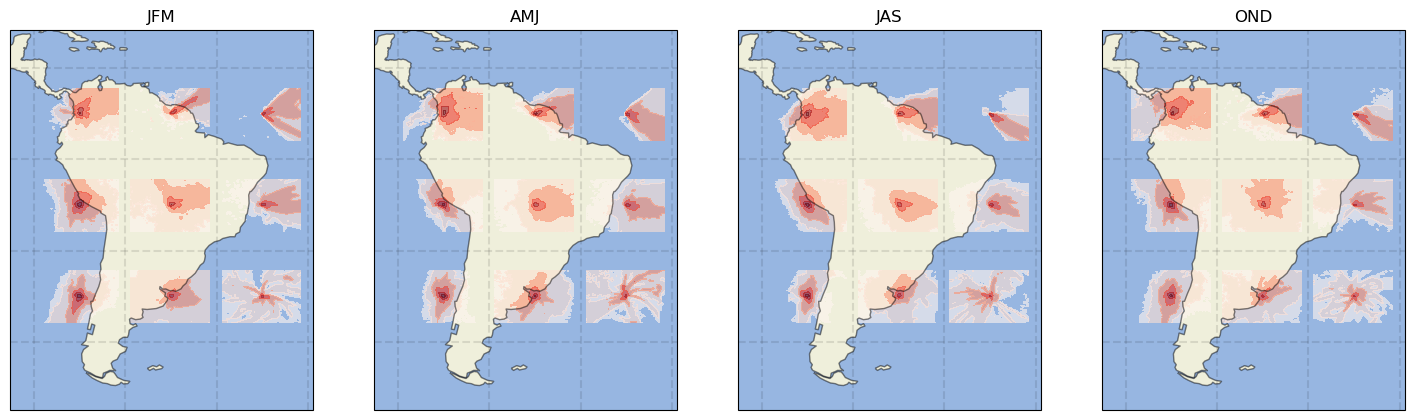

In [15]:
seasons = {"JFM":["01", "02", "03"], "AMJ":["04", "05", "06"], "JAS":["07", "08", "09"], "OND":["10", "11", "12"]}
season_results = {}
degree_bins = 20

release_lons = data.fp_xr.release_lon.values
release_lats = data.fp_xr.release_lat.values

dom_lons = data.fp_data_full.lon.values
dom_lats = data.fp_data_full.lat.values

dates = pd.DatetimeIndex(data.fp_xr.time)

fig, axis = plt.subplots(1,4,figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})

lat_bins = range(int(np.floor(release_lats.min())- degree_bins/2), int(np.ceil(release_lats.max())+ degree_bins/2), degree_bins) 
lon_bins = range(int(np.floor(release_lons.min())- degree_bins/2), int(np.ceil(release_lons.max())+ degree_bins/2), degree_bins) 

for n, seas in enumerate(list(seasons.keys())):
        ax = axis[n]
        print(n, seas)
        #seasonal_idxs = np.bitwise_and(dates.month==m)[0]
        seasonal_idxs = np.where(np.bitwise_and(dates.month>=int(seasons[seas][0]), dates.month<=int(seasons[seas][-1])))[0]

        seasonal_data = data.fp_xr.isel(time=seasonal_idxs)

        binned_fps, lat_edges, lon_edges, binnumber = binned_statistic_2d(
                seasonal_data.release_lat.values,
                seasonal_data.release_lon.values,
                None,
                bins=[lat_bins, lon_bins],
                statistic='count',
                expand_binnumbers=True
                )

        from collections import defaultdict


        #del bin_values

        bin_values = defaultdict(list)

        # if n > 0:
        #         bin_values = {k:[] for k in bin_values.keys()}
        #         bin_values = defaultdict(list)

        levels = [-4, -3.5, -3,  -2.5, -2, -1.5]
        vmin, vmax = (-4, -2)

        deltalat = 0.234
        deltalon = 0.352

        cmap = plt.cm.Reds
        cmap.set_over = "k"
        plot_params = {"transform":cartopy.crs.PlateCarree(), "cmap":cmap, "vmin":vmin, "vmax":vmax}
        alpha =0.4

        for value_i, (lat_bins_h, lon_bins_h) in enumerate(binnumber.T):
                #print(lat_bins_h, lon_bins_h, (lat_bins[lat_bins_h-1], lon_bins[lon_bins_h-1]))
                bin_values[(lat_bins[lat_bins_h-1], lon_bins[lon_bins_h-1])].append(seasonal_data.time.values[value_i])  
                

        extent = (dom_lons[0], dom_lons[-1], dom_lats[0], dom_lats[-1])
        ax.set_extent(extent, crs=cartopy.crs.PlateCarree())

        ax.coastlines(resolution='110m', color='black', linewidth=1, alpha=0.5)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN) 

        #c = 0
        half_size = int(data.size/2)

        for v in list(bin_values.keys()):
                if len(bin_values[v])>3:
                        bin_centre = (v[0]+degree_bins/2, v[1]+degree_bins/2)
                        latitudes_here = sorted(list([bin_centre[0]+deltalat*i for i in range(-half_size, half_size)]))
                        longitudes_here = sorted(list([bin_centre[1]+deltalon*i for i in range(-half_size, half_size)]))

                        f = seasonal_data.fp.sel(time=bin_values[v]).mean(dim="time").values
                        f[f<5e-5] = 0

                        cb = ax.contourf(longitudes_here, latitudes_here, np.log10(f), **plot_params, levels=levels, alpha=0.6, extend="both")

        for lat_edge in lat_edges:
                ax.axhline(lat_edge, ls="--", c="k", alpha=0.1)
        for lon_edge in lon_edges:
                ax.axvline(lon_edge, ls="--", c="k", alpha=0.1)
        


        ax.set_title(seas)
        

In [16]:
from model.data.load_data import LoadSquareSatelliteData

data = LoadSquareSatelliteData(2016, freq=10, size=50, region="SAHARA", load_everything=True, verbose=True, load_fps_as="both")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_2016*.nc
there was an error opening the dataset. checking if any of the files are in the bad files list
at least one of the files was in the bad files list, opening with workaround
reduced the number of datapoints by frequency 10
Loading 902 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the latitude dimension to extract size 50 (0 and 12 idxs on either side) Padding with nan
49 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 5.43% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 49, 'S': 0, 'E': 0, 'W': 0}

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/NORTHAFRICA/NORTHAFRICA_Met_2016*.nc
----- Cutting met


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


calculated wind angle and/or speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


0 JFM
1 AMJ
2 JAS
3 OND


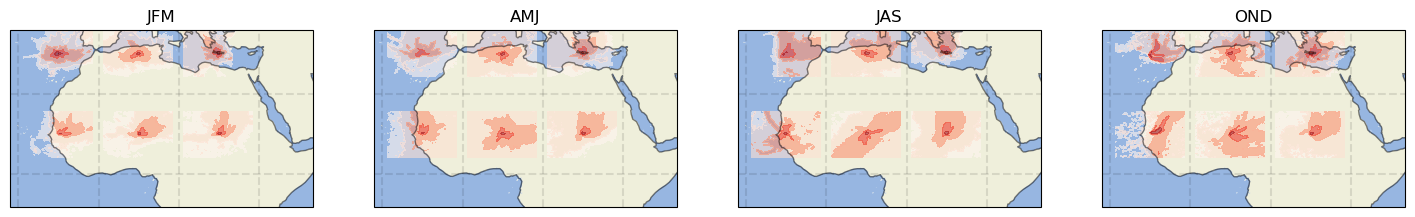

In [ ]:
seasons = {"JFM":["01", "02", "03"], "AMJ":["04", "05", "06"], "JAS":["07", "08", "09"], "OND":["10", "11", "12"]}
season_results = {}
degree_bins = 20

release_lons = data.fp_xr.release_lon.values
release_lats = data.fp_xr.release_lat.values

dom_lons = data.fp_data_full.lon.values[65:-110]
dom_lats = data.fp_data_full.lat.values[50:]

dates = pd.DatetimeIndex(data.fp_xr.time)

fig, axis = plt.subplots(1,4,figsize=(18,12), subplot_kw={'projection': ccrs.PlateCarree()})

lat_bins = range(int(np.floor(release_lats.min())- degree_bins/2), int(np.ceil(release_lats.max())+ degree_bins/2), degree_bins) 
lon_bins = range(int(np.floor(release_lons.min())- degree_bins/2), int(np.ceil(release_lons.max())+ degree_bins/2), degree_bins) 

for n, seas in enumerate(list(seasons.keys())):
        ax = axis[n]
        print(n, seas)
        #seasonal_idxs = np.bitwise_and(dates.month==m)[0]
        seasonal_idxs = np.where(np.bitwise_and(dates.month>=int(seasons[seas][0]), dates.month<=int(seasons[seas][-1])))[0]

        seasonal_data = data.fp_xr.isel(time=seasonal_idxs)

        binned_fps, lat_edges, lon_edges, binnumber = binned_statistic_2d(
                seasonal_data.release_lat.values,
                seasonal_data.release_lon.values,
                None,
                bins=[lat_bins, lon_bins],
                statistic='count',
                expand_binnumbers=True
                )

        from collections import defaultdict


        #del bin_values

        bin_values = defaultdict(list)

        # if n > 0:
        #         bin_values = {k:[] for k in bin_values.keys()}
        #         bin_values = defaultdict(list)

        levels = [-4, -3.5, -3,  -2.5, -2, -1.5]
        vmin, vmax = (-4, -2)

        deltalat = 0.234
        deltalon = 0.352

        cmap = plt.cm.Reds
        cmap.set_over = "k"
        plot_params = {"transform":cartopy.crs.PlateCarree(), "cmap":cmap, "vmin":vmin, "vmax":vmax}
        alpha =0.4

        for value_i, (lat_bins_h, lon_bins_h) in enumerate(binnumber.T):
                #print(lat_bins_h, lon_bins_h, (lat_bins[lat_bins_h-1], lon_bins[lon_bins_h-1]))
                bin_values[(lat_bins[lat_bins_h-1], lon_bins[lon_bins_h-1])].append(seasonal_data.time.values[value_i])  
                

        extent = (dom_lons[0], dom_lons[-1], dom_lats[0], dom_lats[-1])
        ax.set_extent(extent, crs=cartopy.crs.PlateCarree())

        ax.coastlines(resolution='110m', color='black', linewidth=1, alpha=0.5)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN) 

        #c = 0
        half_size = int(data.size/2)

        for v in list(bin_values.keys()):
                if len(bin_values[v])>3:
                        bin_centre = (v[0]+degree_bins/2, v[1]+degree_bins/2)
                        latitudes_here = sorted(list([bin_centre[0]+deltalat*i for i in range(-half_size, half_size)]))
                        longitudes_here = sorted(list([bin_centre[1]+deltalon*i for i in range(-half_size, half_size)]))

                        f = seasonal_data.fp.sel(time=bin_values[v]).mean(dim="time").values
                        f[f<5e-5] = 0

                        cb = ax.contourf(longitudes_here, latitudes_here, np.log10(f), **plot_params, levels=levels, alpha=0.6, extend="both")

        for lat_edge in lat_edges:
                ax.axhline(lat_edge, ls="--", c="k", alpha=0.1)
        for lon_edge in lon_edges:
                ax.axvline(lon_edge, ls="--", c="k", alpha=0.1)
        


        ax.set_title(seas)
        

## plotting footprints - finished plots

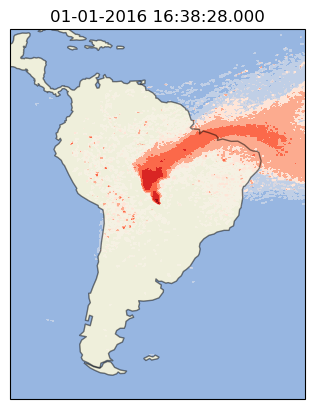

In [28]:
data.plot_footprint(idx=10)

0 JFM
(4459,)
(4459,)
1 AMJ
(5241,)
(5241,)
2 JAS


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


(7400,)
(7400,)
3 OND
(4571,)
(4571,)


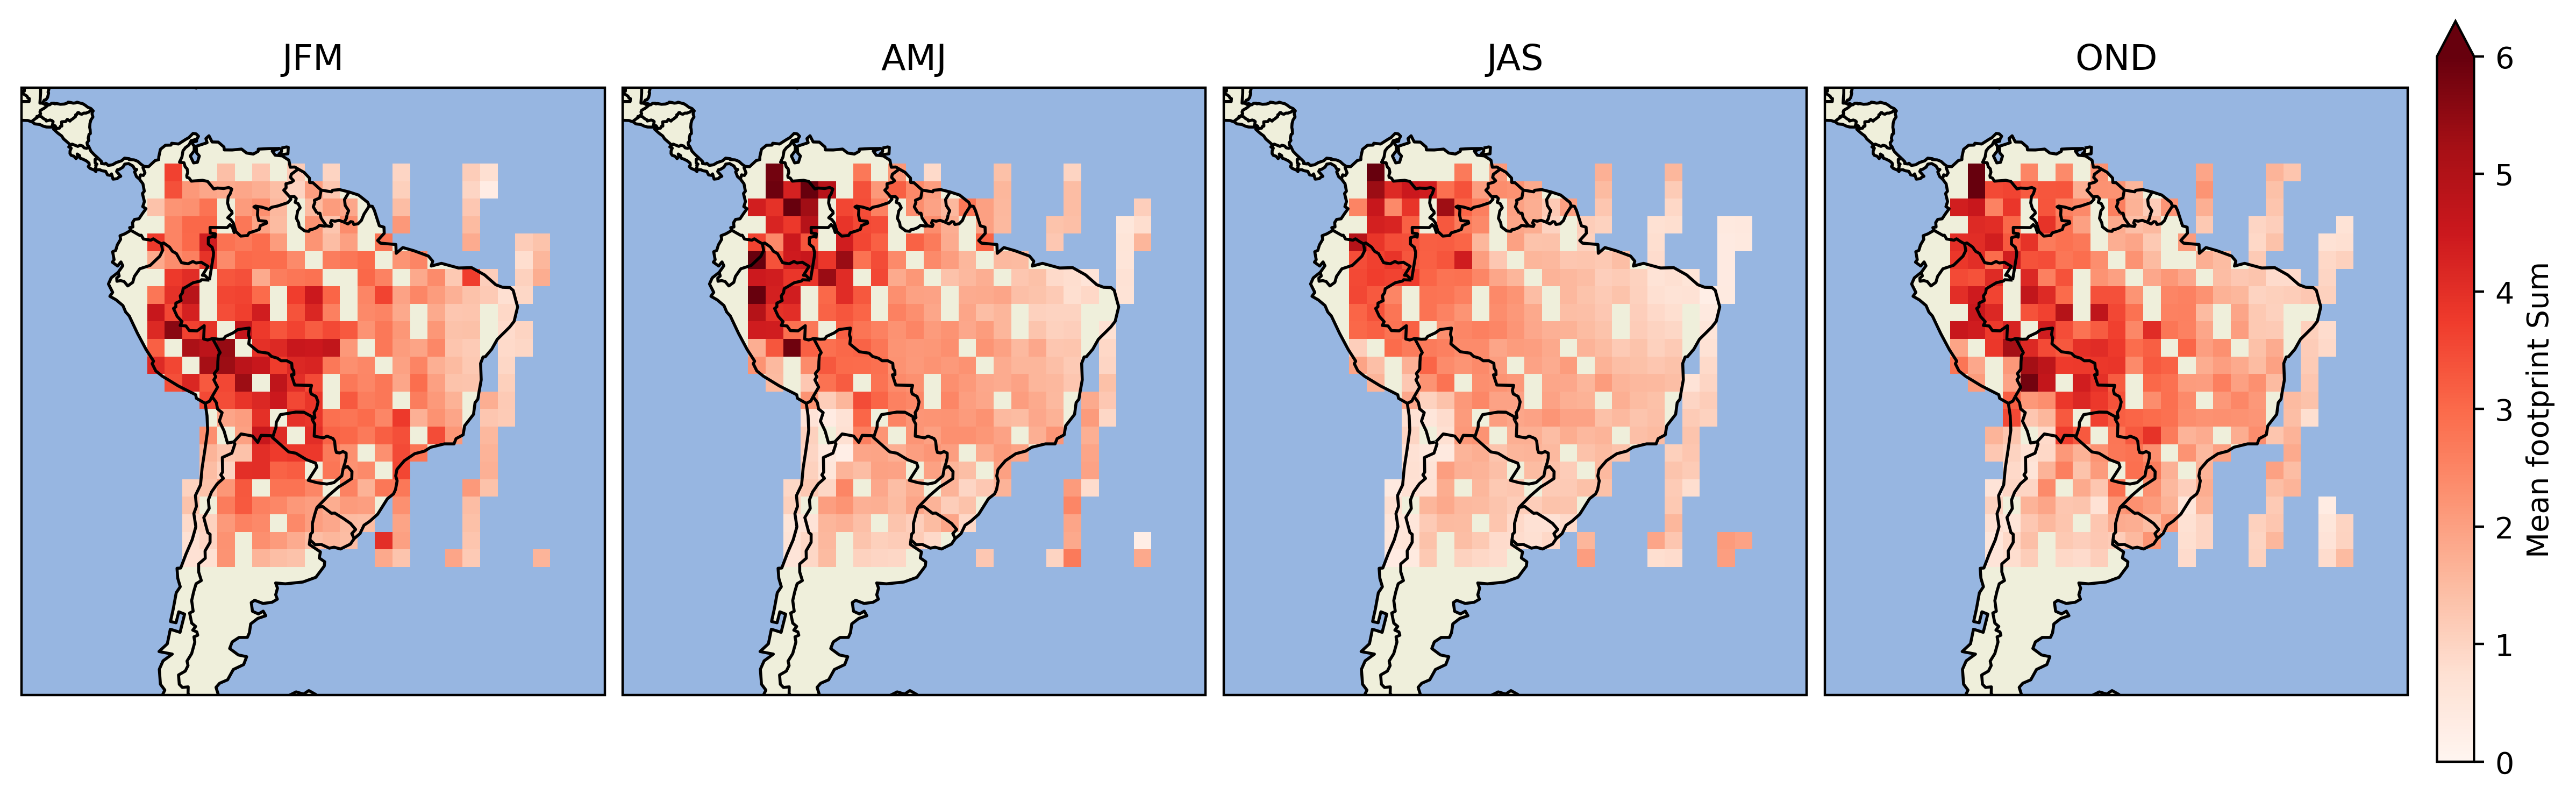

In [18]:
# plot the mean sum of the footprint binned by the measurement location in 2-degree bins

plot_seasonal_footprint_histogram(data.fp_data_full, metric="mean_sum", degree_bins=2, vmin_vmax=[0,6], return_fig=False)

note that vmin_vmax is None, so the color scale will be different for each season, and not comparable across seasons! To compare across seasons, set vmin_vmax to a list of [vmin, vmax] e.g. [0, 10]
0 JFM  - n values: 4459
calculating vmin and vmax from data
1 AMJ  - n values: 5241
calculating vmin and vmax from data
2 JAS  - n values: 7400
calculating vmin and vmax from data
3 OND  - n values: 4571
calculating vmin and vmax from data


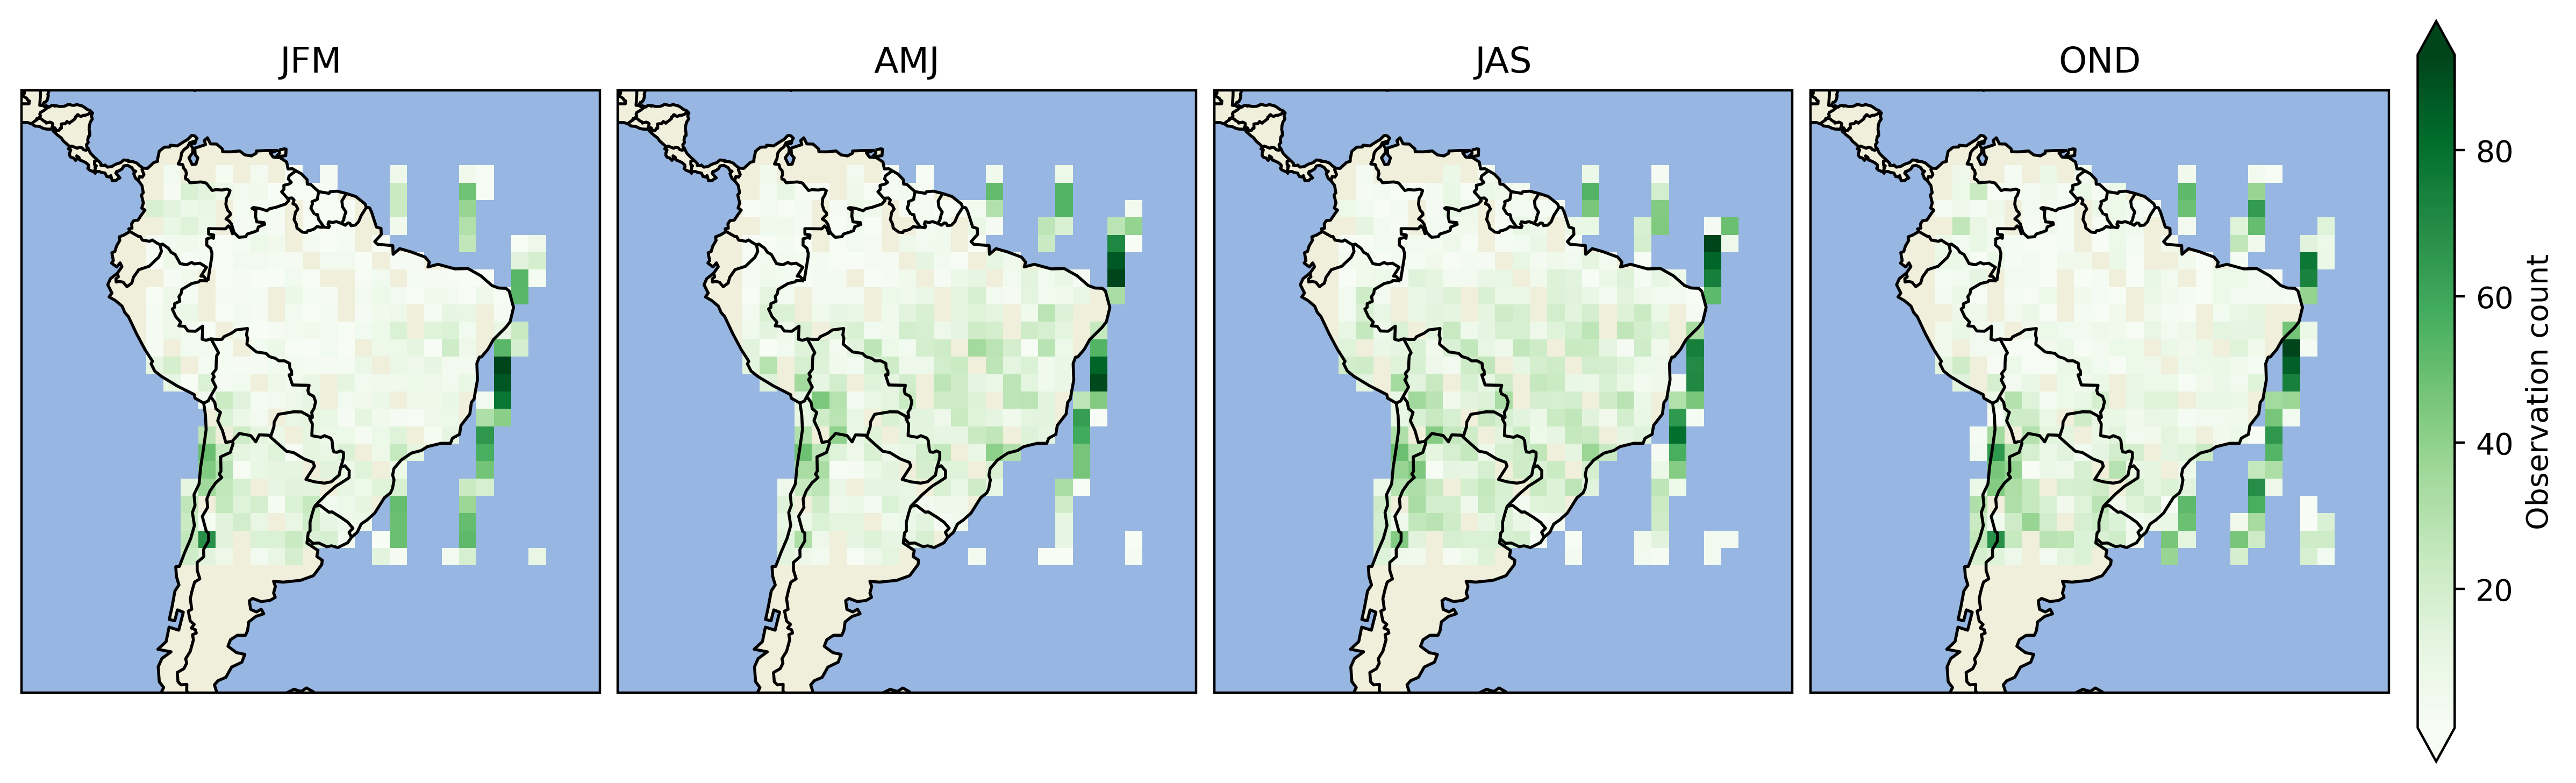

In [20]:
plot_seasonal_footprint_histogram(data.fp_data_full, metric="count", degree_bins=2, return_fig=False)

In [13]:
release_country = data.countries.country.sel(lat=data.fp_data_full.release_lat,  lon=data.fp_data_full.release_lon,  method="nearest"
).astype(int)
data.fp_data_full["release_country"] = release_country

## per country plots

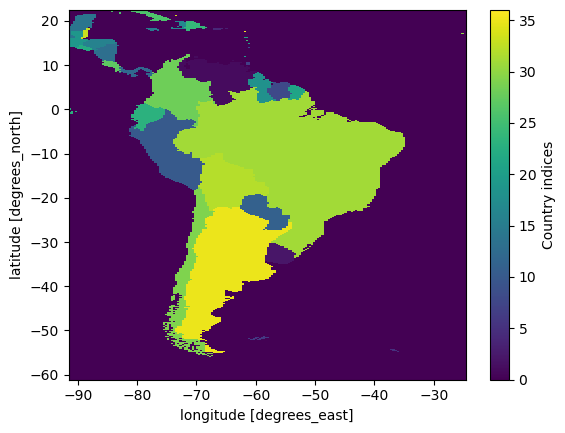

In [50]:
data.countries.country.plot()

([<matplotlib.axis.XTick at 0x7fdb3460ef30>,
 [Text(0, 0, 'OCEAN'),
  Text(1, 0, 'VENEZUELA'),
  Text(2, 0, 'URUGUAY'),
  Text(8, 0, 'SURINAME'),
  Text(10, 0, 'PERU'),
  Text(11, 0, 'PARAGUAY'),
  Text(18, 0, 'GUYANA'),
  Text(21, 0, 'FRANCE'),
  Text(23, 0, 'ECUADOR'),
  Text(28, 0, 'COLOMBIA'),
  Text(29, 0, 'CHILE'),
  Text(31, 0, 'BRAZIL'),
  Text(32, 0, 'BOLIVIA'),
  Text(35, 0, 'ARGENTINA')])

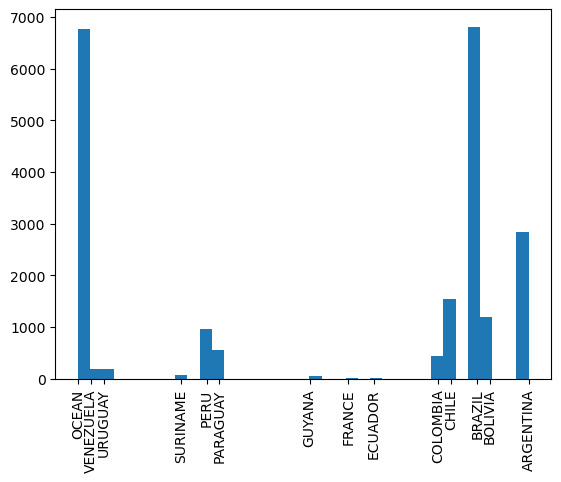

In [15]:
plt.hist(data.fp_data_full.release_country, bins=len(data.countries.name)) #, labels=data.countries.name.values[np.unique(data.fp_data_full.release_country.values)[0]], bins=np.arange(-0.5, len(data.countries.name.values)-0.5, 1), rwidth=0.8)
plt.xticks(np.unique(data.fp_data_full.release_country.values), data.countries.name.values[np.unique(data.fp_data_full.release_country.values)], rotation=90)

In [ ]:
## working one!
data.fp_data_full = data.fp_data_full.assign_coords(release_country=("time", data.fp_data_full.release_country.values))

In [31]:
grouped_stats = data.fp_data_full.fp.sum(dim=["lat", "lon"]).groupby("release_country")

In [ ]:
df.boxplot(column='total_fp', by='release_country', figsize=(12, 6))
plt.xticks(rotation=90)
plt.ylabel("Total Footprint Strength")
plt.title("Distribution of Plume Strength by Country")
plt.suptitle("") # Clear the auto-generated title

In [ ]:
df = data.fp_data_full.fp.sum(dim=["lat", "lon"]).to_dataframe(name='total_fp')

Text(0.5, 0.98, '')

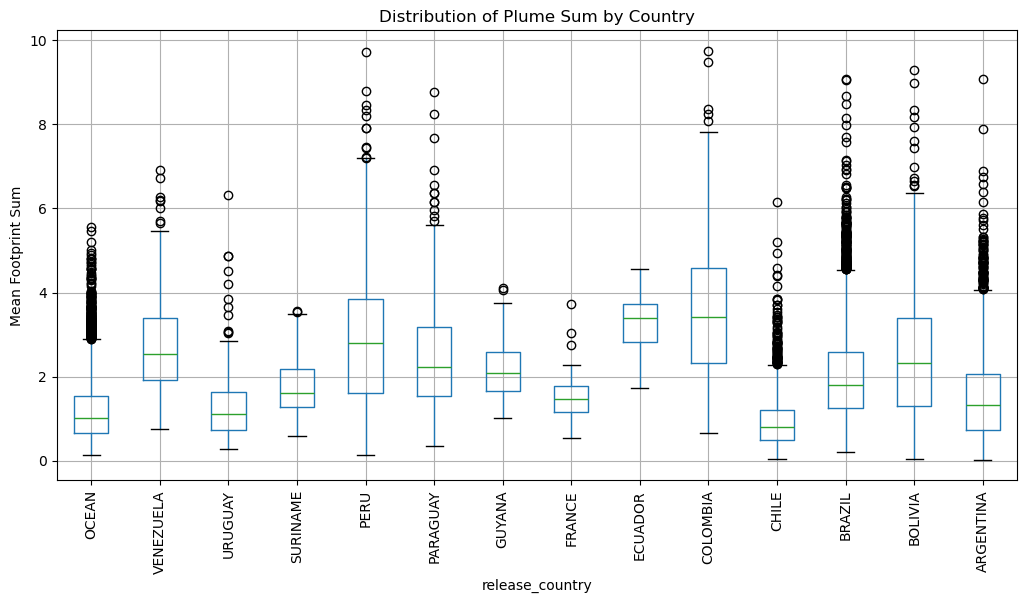

In [49]:

# 2. Use a boxplot grouped by country
df.boxplot(column='total_fp', by='release_country', figsize=(12, 6))
plt.xticks(ticks=np.arange(1, 1+len(np.unique(df.release_country.values))), labels=data.countries.name.values[np.unique(df.release_country.values)], rotation=90)
plt.ylabel("Mean Footprint Sum")
plt.title("Distribution of Plume Sum by Country")
plt.suptitle("") # Clear the auto-generated title

([<matplotlib.axis.XTick at 0x7fdadb4dfe90>,
 [Text(0, 0, 'OCEAN'),
  Text(1, 0, 'VENEZUELA'),
  Text(2, 0, 'URUGUAY'),
  Text(8, 0, 'SURINAME'),
  Text(10, 0, 'PERU'),
  Text(11, 0, 'PARAGUAY'),
  Text(18, 0, 'GUYANA'),
  Text(21, 0, 'FRANCE'),
  Text(23, 0, 'ECUADOR'),
  Text(28, 0, 'COLOMBIA'),
  Text(29, 0, 'CHILE'),
  Text(31, 0, 'BRAZIL'),
  Text(32, 0, 'BOLIVIA'),
  Text(35, 0, 'ARGENTINA')])

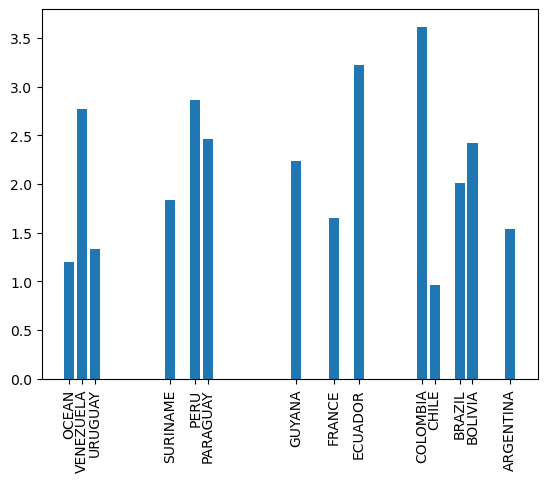

In [41]:
plt.bar(grouped_stats.mean().release_country.valuesgrouped_stats.mean().values, bins=20)
plt.xticks(np.unique(data.fp_data_full.release_country.values), data.countries.name.values[np.unique(data.fp_data_full.release_country.values)], rotation=90)

# plotting met by footprints

In [5]:
from model.data.load_data import LoadSquareSatelliteData

data = LoadSquareSatelliteData(2016, freq=10, size=50, region="BRAZIL", load_everything=True, verbose=True, load_fps_as="both")
#data = LoadSquareSatelliteData(2016, freq=10, size=50, region="SAHARA", load_everything=True, verbose=True, load_fps_as="both")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
reduced the number of datapoints by frequency 10
Loading 2168 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the longitude dimension to extract size 50 (0 and 2 idxs on either side) Padding with nan
35 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 1.61% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 0, 'S': 0, 'E': 35, 'W': 0}

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc
----- Cutting met


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockw

calculated wind angle and/or speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


0 JFM  - n values: 446
1 AMJ  - n values: 524
2 JAS  - n values: 740
3 OND  - n values: 458


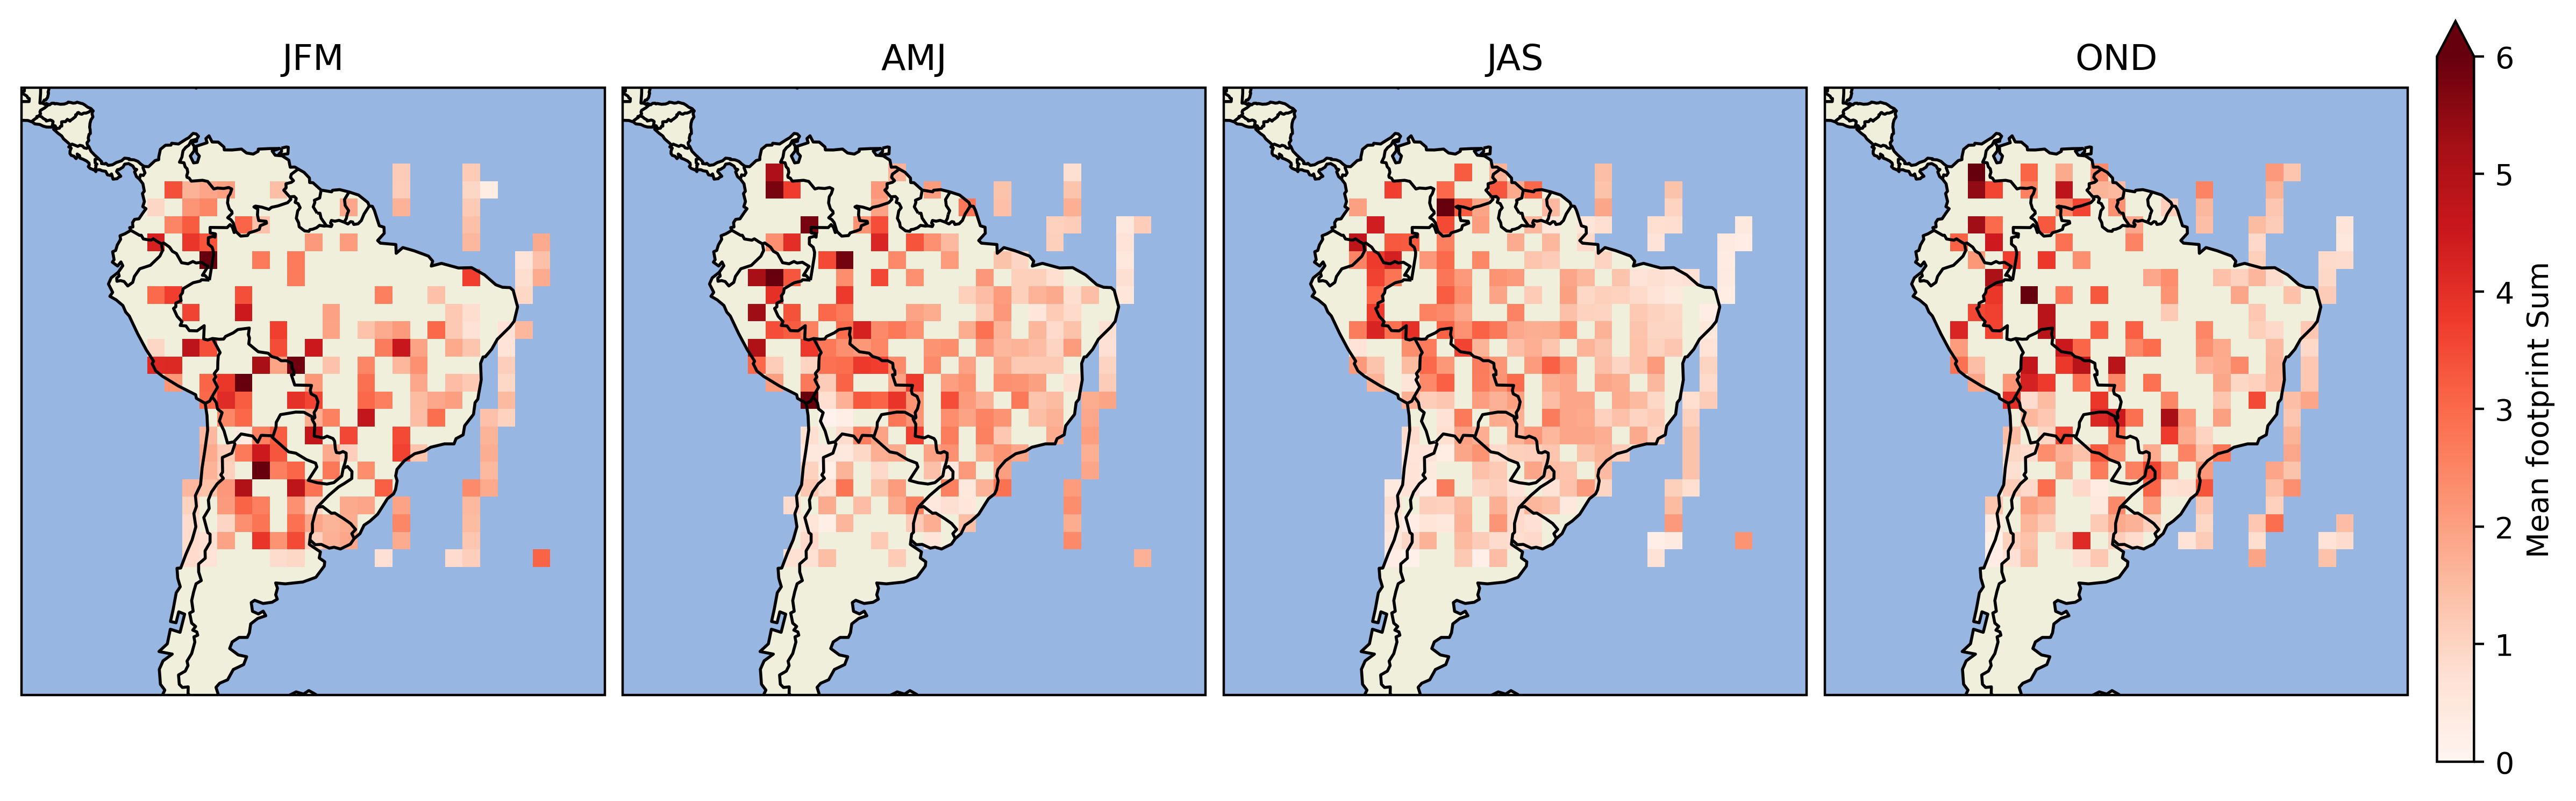

In [ ]:
# plot the count of the footprint binned by the measurement location in 2-degree bins
# plot the sum of the subsampled footprints!
plot_seasonal_footprint_histogram(data.fp_data_full, metric="mean_sum", degree_bins=2, vmin_vmax=[0,6], return_fig=False)

In [7]:
S = data.size  # or however S is defined in your setup
center = int(S / 2)

u = data.met.x_wind.sel(levels=3, lat=center, lon=center).chunk({'time': -1}).load()
v = data.met.y_wind.sel(levels=3, lat=center, lon=center).chunk({'time': -1}).load()

In [8]:
data.fp_xr["fp_sum"] = data.fp_xr.fp.sum(dim=['lat', 'lon'])

In [9]:
def plot_scatter_rose(u, v, fp_sum=None, title='', 
                      show_colorbar=True, axis=None, cmap='viridis', figsize=(6, 6), vmax=None, vmax_speed=None, cbar_label=""):
    """
    Plot a polar scatter wind rose.
    
    Parameters
    ----------
    u, v : array-like
        Wind components (x and y).
    fp_sum : array-like, optional
        Footprint sum for coloring points. If None, points are plain steelblue.
    title : str, optional
        Plot title.
    show_colorbar : bool, optional
        Whether to show the colorbar. Only relevant if fp_sum is provided.
    cmap : str, optional
        Colormap for fp_sum.
    figsize : tuple, optional
        Figure size.
    """
    speed = np.sqrt(u**2 + v**2)
    wind_dir_rad = np.deg2rad(270 - np.rad2deg(np.arctan2(v, u))) % (2 * np.pi)

    if axis is not None:
        ax = axis
        fig = ax.get_figure()
    else:
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=figsize)

    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)


    # Colorscale
    if fp_sum is not None:
        fp_values = np.asarray(fp_sum)
        _vmax = vmax if vmax is not None else np.nanpercentile(fp_values, 98)
        norm = mcolors.Normalize(vmin=0, vmax=_vmax)
        scatter = ax.scatter(wind_dir_rad, speed, c=fp_values, cmap=cmap,
                             norm=norm, alpha=0.6, s=20)
        if show_colorbar and axis is None:
            cbar = fig.colorbar(scatter, ax=ax, orientation='vertical', pad=0.1, shrink=0.7, extend="max")
            cbar.set_label(cbar_label)
        elif show_colorbar and axis is not None:
            pos = ax.get_position()
            cax = fig.add_axes([pos.x1 + 0.1, pos.y0, 0.02, pos.height])
            cbar = fig.colorbar(scatter, cax=cax, orientation='vertical',  shrink=0.7, extend='max')
            cbar.set_label(cbar_label)
    else:
        scatter = ax.scatter(wind_dir_rad, speed, color='steelblue', alpha=0.6, s=20)

    # Radial ticks
    max_speed = vmax_speed if vmax_speed is not None else np.nanpercentile(speed, 98)
    step = np.round(max_speed / 4, decimals=0)
    ticks = np.arange(step, max_speed + 0.5*step, step).astype(int)
    ax.set_rticks(ticks)
    ax.set_rmax(max_speed*1.1)
    ax.set_rlabel_position(90)

    ax.set_title(title, va='bottom')

    if axis is None:
        plt.tight_layout()
        return fig, ax

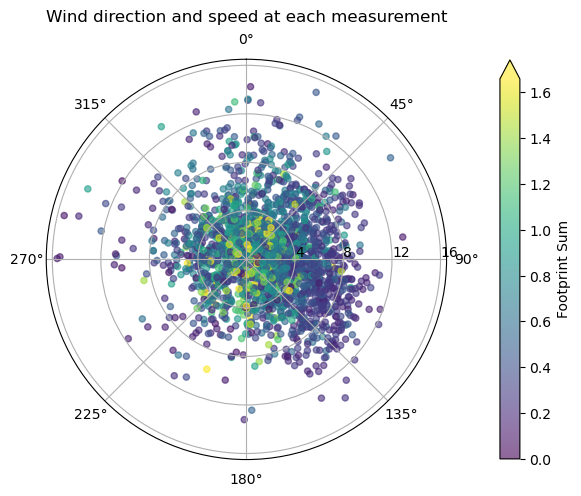

In [92]:
# with S=50
fig, ax = plot_scatter_rose(u, v, fp_sum=data.fp_xr.fp_sum.values, vmax_speed=15, title='Wind direction and speed at each measurement', cbar_label="Footprint Sum")

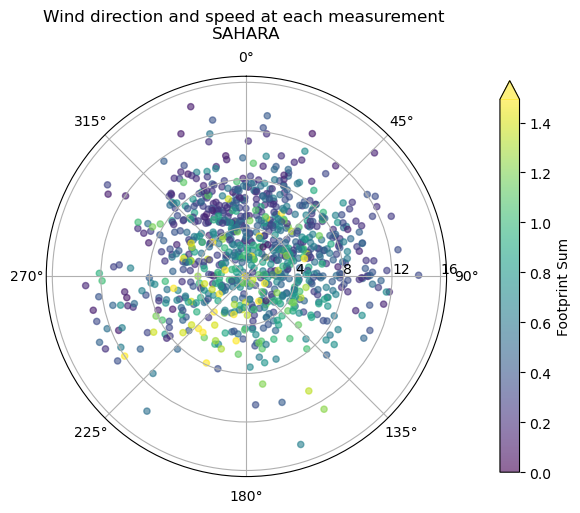

In [12]:
# with S=50
fig, ax = plot_scatter_rose(u, v, fp_sum=data.fp_xr.fp_sum.values, vmax_speed=15, title='Wind direction and speed at each measurement \nSAHARA', cbar_label="Footprint Sum")

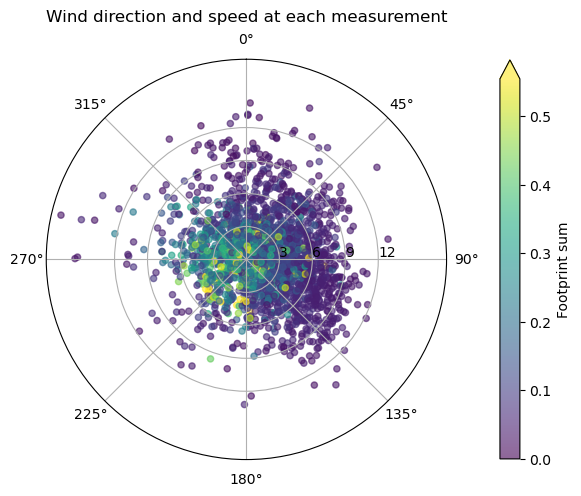

In [ ]:
# with S=10
fig, ax = plot_scatter_rose(u, v, fp_sum=data.fp_xr.fp_sum.values, title='Wind direction and speed at each measurement', cbar_label="Footprint Sum")

/tmp/ipykernel_1704886/668215215.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


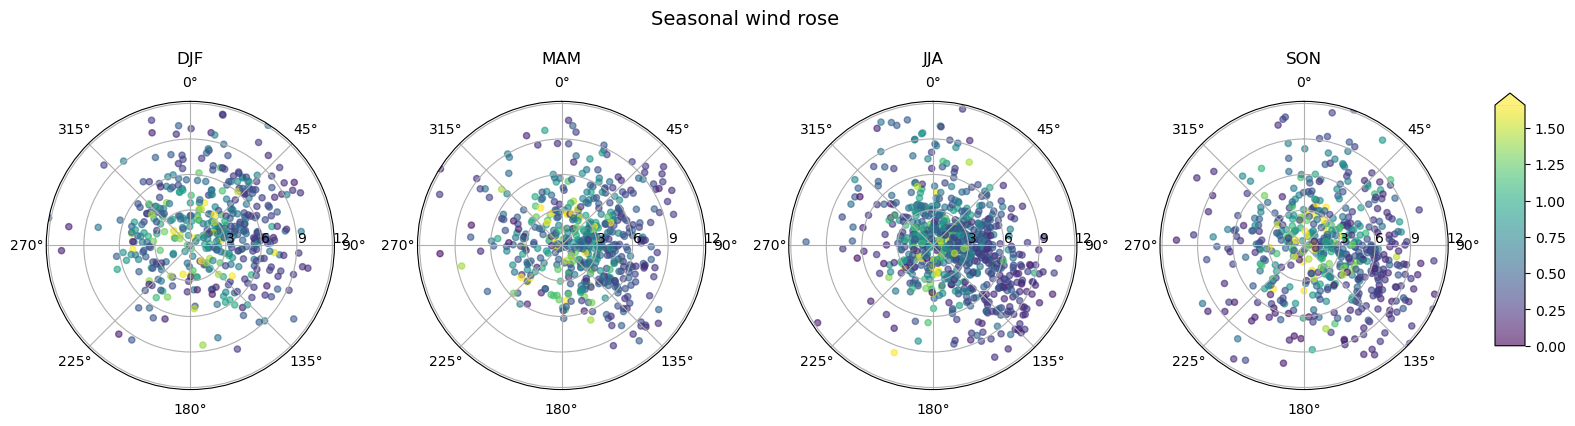

In [94]:
season_order = ['DJF', 'MAM', 'JJA', 'SON']

# Compute a shared vmax across all seasons
vmax_global = np.nanpercentile(data.fp_xr.fp_sum.values, 98)
vmax_speed_global = np.nanpercentile(np.sqrt(u**2 + v**2), 98)

fig, axes = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={'projection': 'polar'})
axes = axes.flatten()

u_grouped = u.groupby('time.season')
v_grouped = v.groupby('time.season')
fp_grouped = data.fp_xr.fp_sum.groupby('time.season')

for ax, season_name in zip(axes, season_order):
    u_s = u_grouped[season_name]
    v_s = v_grouped[season_name]
    fp_s = fp_grouped[season_name].values

    is_last = (season_name == season_order[-1])

    plot_scatter_rose(u_s, v_s, fp_sum=fp_s, title=season_name,
                      show_colorbar=is_last, axis=ax,
                      vmax=vmax_global, vmax_speed=vmax_speed_global)

fig.suptitle('Seasonal wind rose', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2143296/2571532309.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


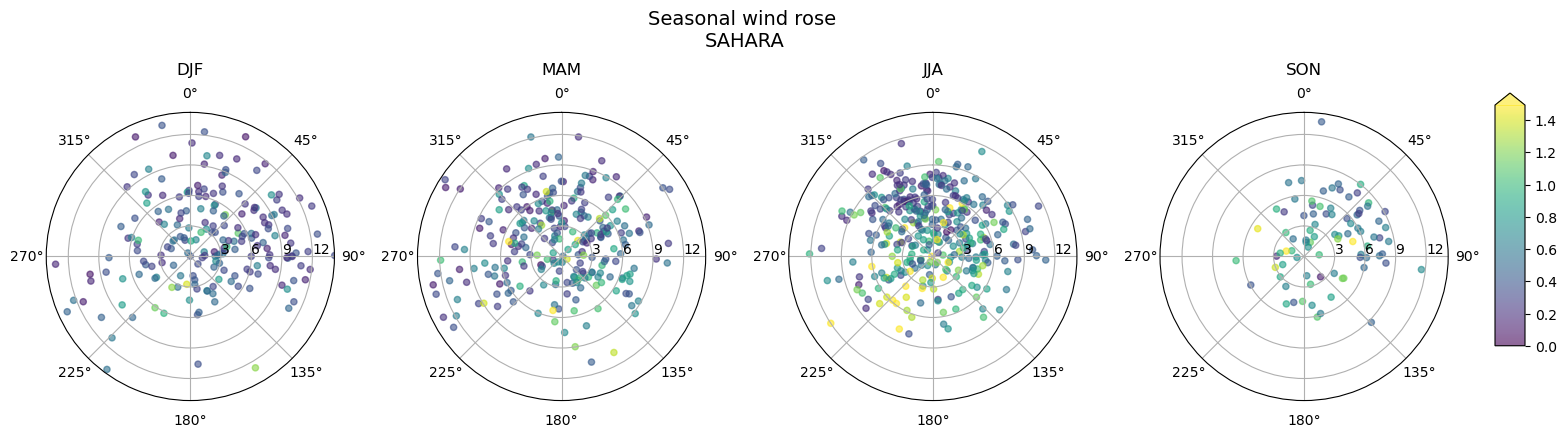

In [13]:
season_order = ['DJF', 'MAM', 'JJA', 'SON']

# Compute a shared vmax across all seasons
vmax_global = np.nanpercentile(data.fp_xr.fp_sum.values, 98)
vmax_speed_global = np.nanpercentile(np.sqrt(u**2 + v**2), 98)

fig, axes = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={'projection': 'polar'})
axes = axes.flatten()

u_grouped = u.groupby('time.season')
v_grouped = v.groupby('time.season')
fp_grouped = data.fp_xr.fp_sum.groupby('time.season')

for ax, season_name in zip(axes, season_order):
    u_s = u_grouped[season_name]
    v_s = v_grouped[season_name]
    fp_s = fp_grouped[season_name].values

    is_last = (season_name == season_order[-1])

    plot_scatter_rose(u_s, v_s, fp_sum=fp_s, title=season_name,
                      show_colorbar=is_last, axis=ax,
                      vmax=vmax_global, vmax_speed=vmax_speed_global)

fig.suptitle('Seasonal wind rose \nSAHARA', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
u_all = data.met.x_wind.sel(levels=[1, 3, 12, 27], lat=center, lon=center).load()
v_all = data.met.y_wind.sel(levels=[1, 3, 12, 27], lat=center, lon=center).load()

/tmp/ipykernel_1704886/1331765745.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


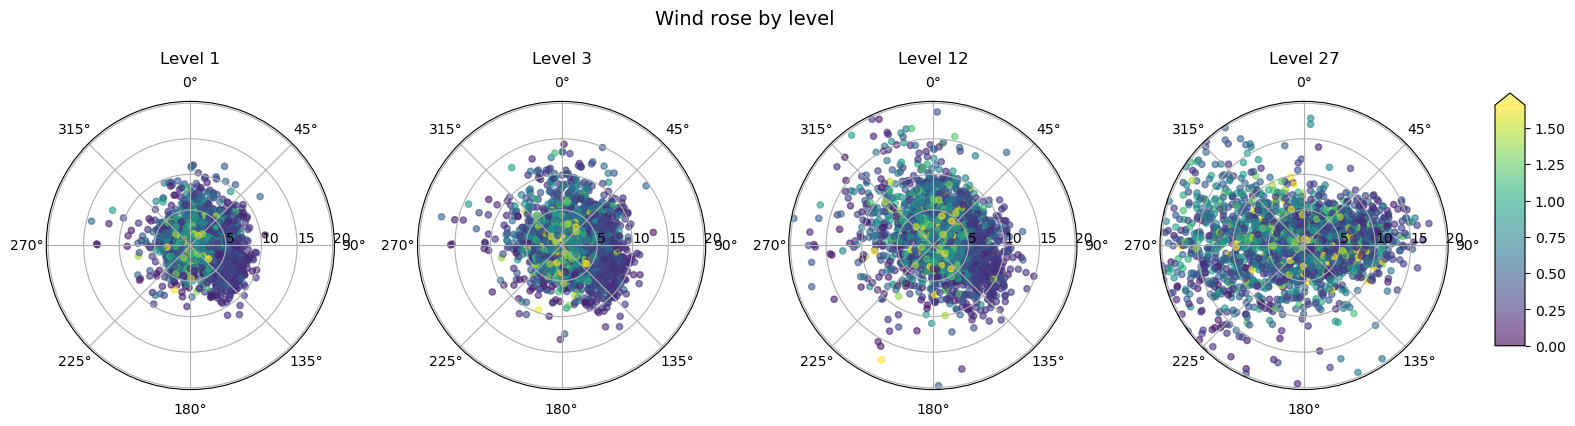

In [96]:
levels = [1, 3, 12, 27]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={'projection': 'polar'})

vmax_global = np.nanpercentile(data.fp_xr.fp_sum.values, 98)
vmax_speed_global = np.nanpercentile(np.sqrt(u_all**2 + v_all**2), 98)

for ax, level in zip(axes, levels):
    u_l = u_all.sel(levels=level)
    v_l = v_all.sel(levels=level)

    is_last = (level == levels[-1])

    plot_scatter_rose(u_l, v_l, fp_sum=data.fp_xr.fp_sum.values,
                      title=f'Level {level}',
                      show_colorbar=is_last,
                      axis=ax,
                      vmax=vmax_global, vmax_speed=vmax_speed_global)

fig.suptitle('Wind rose by level', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2143296/27557408.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


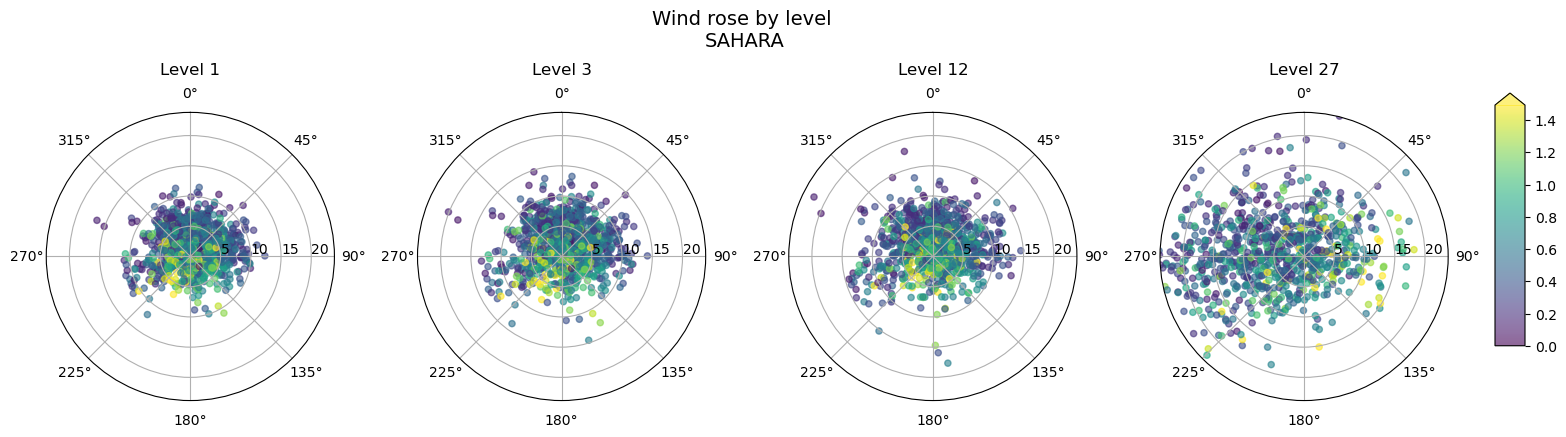

In [15]:
levels = [1, 3, 12, 27]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), subplot_kw={'projection': 'polar'})

vmax_global = np.nanpercentile(data.fp_xr.fp_sum.values, 98)
vmax_speed_global = np.nanpercentile(np.sqrt(u_all**2 + v_all**2), 98)

for ax, level in zip(axes, levels):
    u_l = u_all.sel(levels=level)
    v_l = v_all.sel(levels=level)

    is_last = (level == levels[-1])

    plot_scatter_rose(u_l, v_l, fp_sum=data.fp_xr.fp_sum.values,
                      title=f'Level {level}',
                      show_colorbar=is_last,
                      axis=ax,
                      vmax=vmax_global, vmax_speed=vmax_speed_global)

fig.suptitle('Wind rose by level \nSAHARA', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

plotting wind arrow at lat -22.371000289916992 and lon -61.409000396728516 with u 1.3856619596481323 and v 5.439248561859131
plotting wind arrow at lat -22.371000289916992 and lon -61.409000396728516 with u 2.112159252166748 and v 8.643675804138184
plotting wind arrow at lat -22.371000289916992 and lon -61.409000396728516 with u 2.076704502105713 and v 12.286332130432129


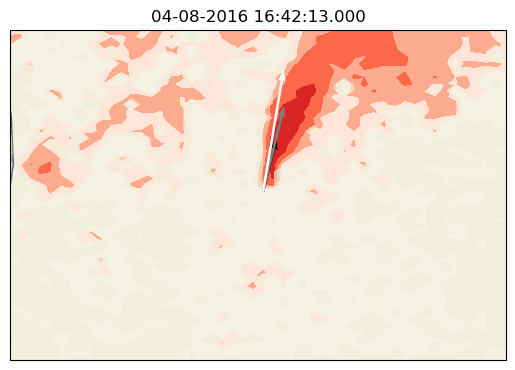

In [79]:
fig, ax = data.plot_cropped_footprint(idx=1250, return_fig=True, plot_wind=True)

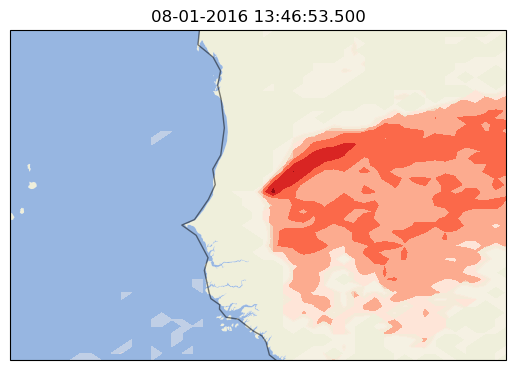

In [17]:
fig, ax = data.plot_cropped_footprint(idx=25, return_fig=True)

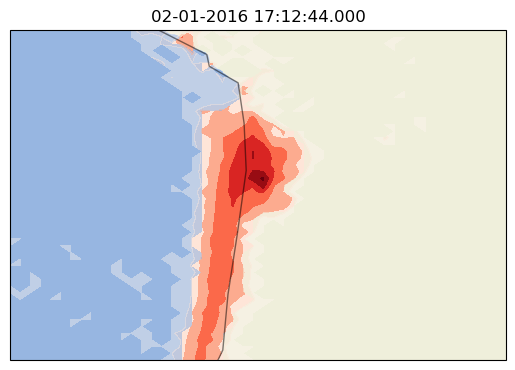

In [12]:
fig, ax = data.plot_cropped_footprint(idx=5, return_fig=True)

In [98]:
level = 3
upwind_distance = 20  # grid cells

u_c = data.met.x_wind.sel(levels=level, lat=center, lon=center).load()
v_c = data.met.y_wind.sel(levels=level, lat=center, lon=center).load()

In [99]:
speed_c = np.sqrt(u_c**2 + v_c**2)
dir_c = (270 - np.rad2deg(np.arctan2(v_c, u_c))) % 360  # meteorological convention

dir_rad = np.deg2rad(dir_c)
offset_lat = np.round(upwind_distance * np.cos(dir_rad)).astype(int)
offset_lon = np.round(upwind_distance * np.sin(dir_rad)).astype(int)

lat_upwind = (center + offset_lat).clip(0, S - 1)
lon_upwind = (center + offset_lon).clip(0, S - 1)
print("doing the selecting")
u_up = data.met.x_wind.sel(levels=level).isel(lat=lat_upwind, lon=lon_upwind).load()
v_up = data.met.y_wind.sel(levels=level).isel(lat=lat_upwind, lon=lon_upwind).load()

speed_up = np.sqrt(u_up**2 + v_up**2)
dir_up = (270 - np.rad2deg(np.arctan2(v_up, u_up))) % 360

# --- Differences ---
delta_speed = speed_up - speed_c.values
delta_dir = ((dir_up - dir_c.values) + 180) % 360 - 180  # signed angle difference [-180, 180]

doing the selecting


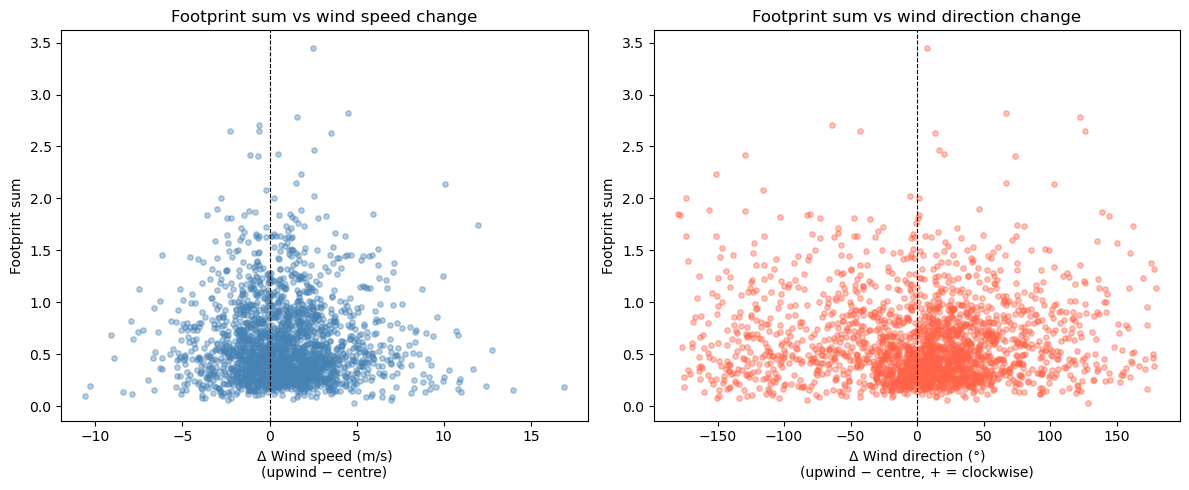

In [101]:
fp_sum = data.fp_xr.fp_sum.values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Delta speed ---
axes[0].scatter(delta_speed, fp_sum, alpha=0.4, s=15, color='steelblue')
axes[0].axvline(0, color='k', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Δ Wind speed (m/s)\n(upwind − centre)')
axes[0].set_ylabel('Footprint sum')
#axes[0].set_yscale('log')
axes[0].set_title('Footprint sum vs wind speed change')

# --- Delta direction ---
axes[1].scatter(delta_dir, fp_sum, alpha=0.4, s=15, color='tomato')
axes[1].axvline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Δ Wind direction (°)\n(upwind − centre, + = clockwise)')
axes[1].set_ylabel('Footprint sum')
#axes[1].set_yscale('log')
axes[1].set_title('Footprint sum vs wind direction change')

plt.tight_layout()
plt.show()

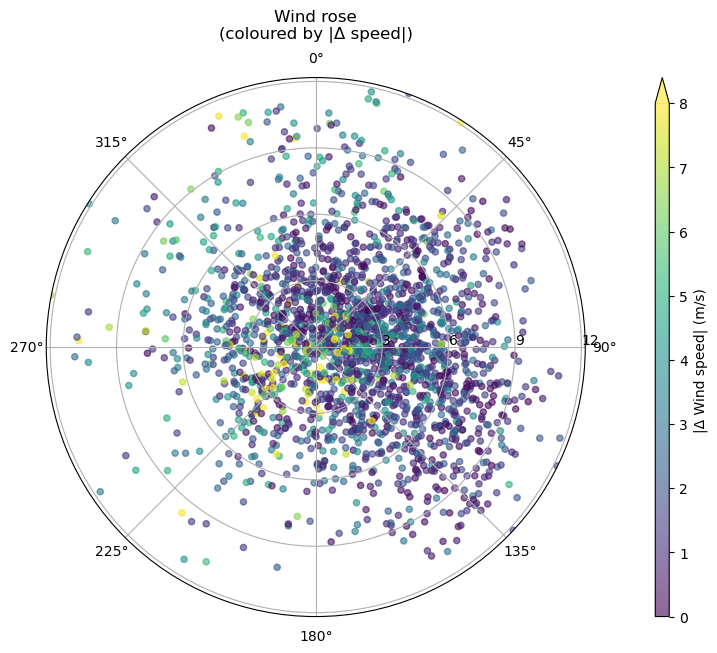

In [102]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
plot_scatter_rose(u_c, v_c, fp_sum=np.abs(delta_speed),
                  title='Wind rose\n(coloured by |Δ speed|)', figsize=(4,4),
                  axis=ax, cmap='viridis', vmax=8, cbar_label='|Δ Wind speed| (m/s)')

In [18]:
threshold = 1e-4
# Boolean mask of pixels above threshold, summed over spatial dims
fp_extent = (data.fp_xr.fp > threshold).sum(dim=['lat', 'lon'])

# Add to dataset
data.fp_xr = data.fp_xr.assign(fp_extent=fp_extent)

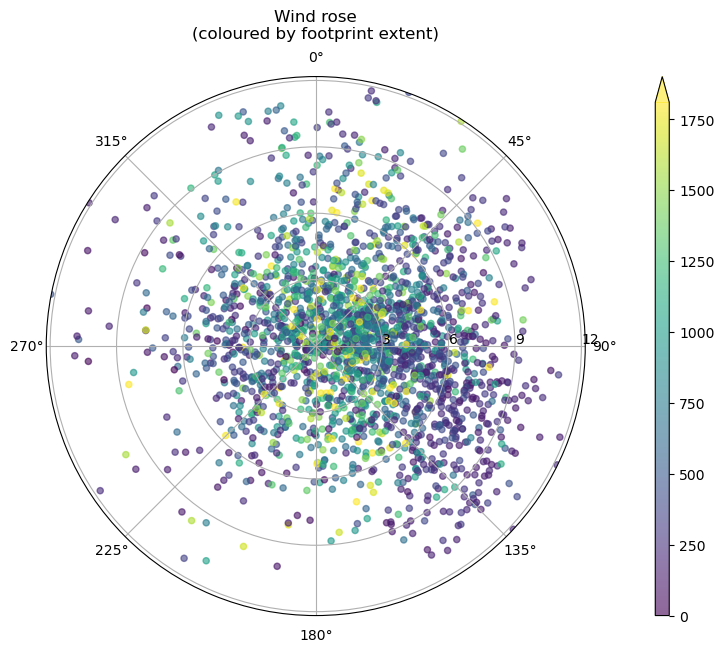

In [104]:
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
plot_scatter_rose(u_c, v_c, fp_sum=data.fp_xr.fp_extent.values,
                  title='Wind rose\n(coloured by footprint extent)',
                  axis=ax, cmap='viridis', cbar_label='Footprint extent (count of pixels > 1e-4)')

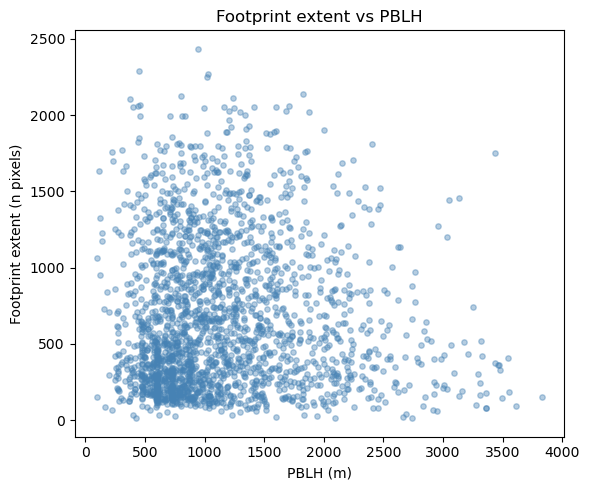

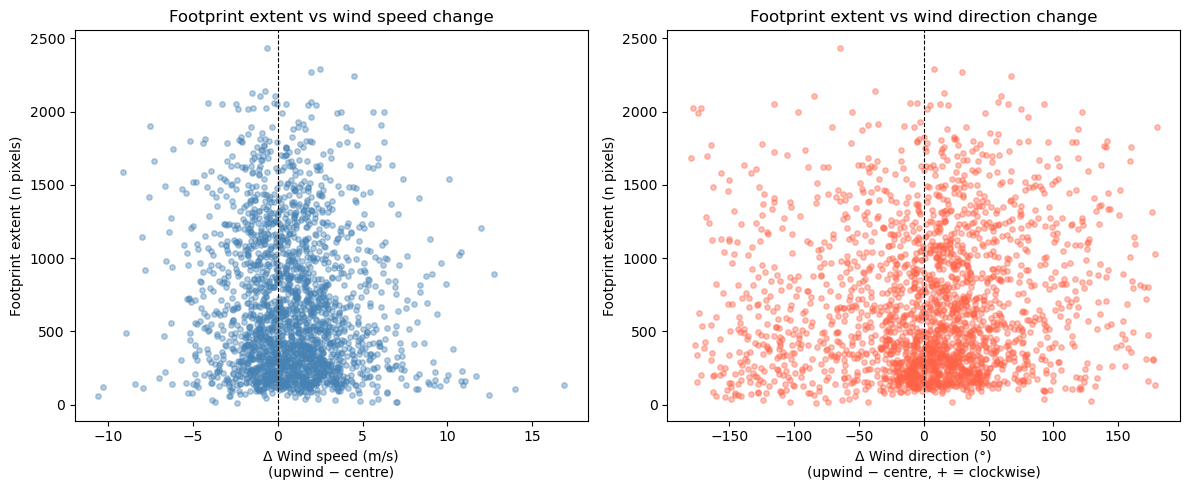

In [105]:
fp_extent = data.fp_xr.fp_extent.values

# --- vs PBLH ---
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(pblh.values, fp_extent, alpha=0.4, s=15, color='steelblue')
ax.set_xlabel('PBLH (m)')
ax.set_ylabel('Footprint extent (n pixels)')
ax.set_title('Footprint extent vs PBLH')
plt.tight_layout()
plt.show()

# --- vs wind deltas ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(delta_speed, fp_extent, alpha=0.4, s=15, color='steelblue')
axes[0].axvline(0, color='k', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Δ Wind speed (m/s)\n(upwind − centre)')
axes[0].set_ylabel('Footprint extent (n pixels)')
axes[0].set_title('Footprint extent vs wind speed change')

axes[1].scatter(delta_dir, fp_extent, alpha=0.4, s=15, color='tomato')
axes[1].axvline(0, color='k', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Δ Wind direction (°)\n(upwind − centre, + = clockwise)')
axes[1].set_ylabel('Footprint extent (n pixels)')
axes[1].set_title('Footprint extent vs wind direction change')

plt.tight_layout()
plt.show()

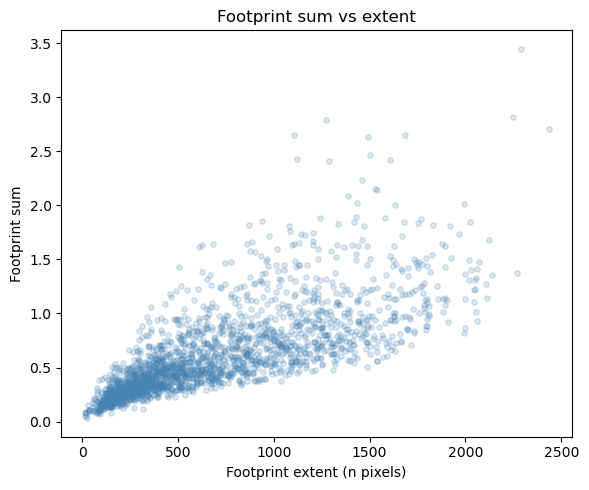

In [107]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(data.fp_xr.fp_extent.values, data.fp_xr.fp_sum.values,
           alpha=0.2, s=15, color='steelblue')
ax.set_xlabel('Footprint extent (n pixels)')
ax.set_ylabel('Footprint sum')
#ax.set_yscale('log')
ax.set_title('Footprint sum vs extent')
plt.tight_layout()
plt.show()

## fp extent vs sum

In [38]:
from model.data.load_data import LoadSquareSatelliteData

data_br = LoadSquareSatelliteData(2016, freq=10, size=50, region="BRAZIL", load_everything=True, verbose=True, load_fps_as="both")
#data = LoadSquareSatelliteData(2016, freq=10, size=50, region="SAHARA", load_everything=True, verbose=True, load_fps_as="both")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
reduced the number of datapoints by frequency 10
Loading 2168 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the longitude dimension to extract size 50 (0 and 2 idxs on either side) Padding with nan
35 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 1.61% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 0, 'S': 0, 'E': 35, 'W': 0}

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc
----- Cutting met


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockw

calculated wind angle and/or speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


In [39]:
data_br.fp_xr["fp_sum"] = data_br.fp_xr.fp.sum(dim=['lat', 'lon'])

threshold = 1e-4
# Boolean mask of pixels above threshold, summed over spatial dims
fp_extent = (data_br.fp_xr.fp > threshold).sum(dim=['lat', 'lon'])

# Add to dataset
data_br.fp_xr = data_br.fp_xr.assign(fp_extent=fp_extent)

higher_threshold = 1e-3
# Boolean mask of pixels above threshold, summed over spatial dims
fp_higher_extent = (data_br.fp_xr.fp > higher_threshold).sum(dim=['lat', 'lon'])

# Add to dataset
data_br.fp_xr = data_br.fp_xr.assign(fp_higher_extent=fp_higher_extent)

In [35]:
data.fp_xr["fp_sum"] = data.fp_xr.fp.sum(dim=['lat', 'lon'])

threshold = 1e-4
# Boolean mask of pixels above threshold, summed over spatial dims
fp_extent = (data.fp_xr.fp > threshold).sum(dim=['lat', 'lon'])

# Add to dataset
data.fp_xr = data.fp_xr.assign(fp_extent=fp_extent)

higher_threshold = 1e-3
# Boolean mask of pixels above threshold, summed over spatial dims
fp_higher_extent = (data.fp_xr.fp > higher_threshold).sum(dim=['lat', 'lon'])

# Add to dataset
data.fp_xr = data.fp_xr.assign(fp_higher_extent=fp_higher_extent)

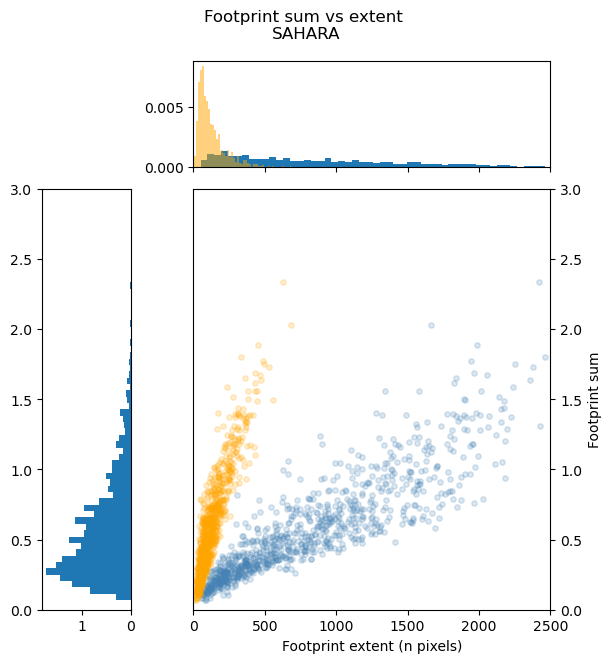

In [41]:
def scatter_hist(x, y, ax, ax_histx, ax_histy, x2=None):
    # no labels
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelright=False)

    # the scatter plot:
    ax.scatter(x, y, alpha=0.2, s=15, color='steelblue')
    if x2 is not None:
        ax.scatter(x2, y, alpha=0.2, s=15, color='orange')

    ax_histx.hist(x, bins=50, density=True)
    if x2 is not None:
        ax_histx.hist(x2, bins=50, alpha=0.5, color='orange', density=True)

    ax.set_ylim(ymin=0, ymax=3)
    ax_histy.set_ylim(ymin=0, ymax=3)

    ax.set_xlim(xmin=0, xmax=data.size**2)  # max possible extent is all pixels in the domain
    ax_histx.set_xlim(xmin=0, xmax=data.size**2)

    ax_histy.hist(y, bins=50, orientation='horizontal', density=True)
    ax_histy.xaxis.set_inverted(True)

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()

    ax.set_xlabel('Footprint extent (n pixels)')
    ax.set_ylabel('Footprint sum')



fig, axs = plt.subplot_mosaic([['.', 'histx'],
                               ['histy','scatter']],
                              figsize=(6, 6),
                              width_ratios=(1, 4), height_ratios=(1, 4),
                              layout='constrained')

scatter_hist(data.fp_xr.fp_extent.values, data.fp_xr.fp_sum.values, axs['scatter'], axs['histx'], axs['histy'], x2=data.fp_xr.fp_higher_extent.values)
fig.suptitle('Footprint sum vs extent \nSAHARA', y=1.08)
plt.show()

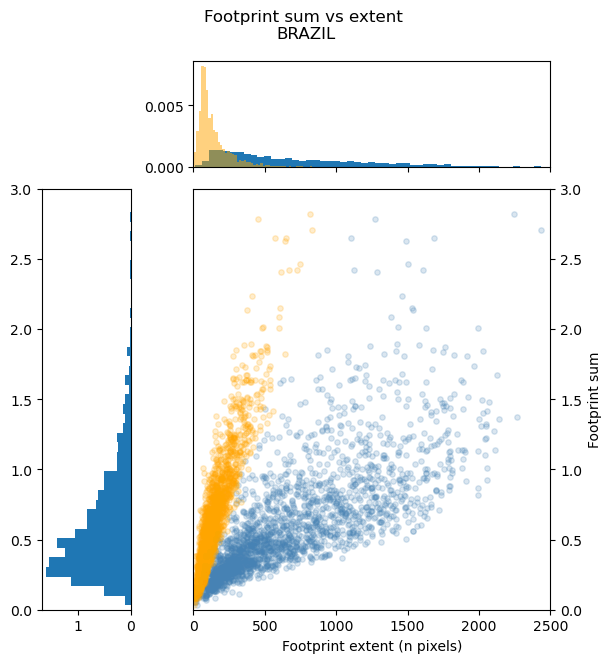

In [42]:
fig, axs = plt.subplot_mosaic([['.', 'histx'],
                               ['histy','scatter']],
                              figsize=(6, 6),
                              width_ratios=(1, 4), height_ratios=(1, 4),
                              layout='constrained')

scatter_hist(data_br.fp_xr.fp_extent.values, data_br.fp_xr.fp_sum.values, axs['scatter'], axs['histx'], axs['histy'], x2=data_br.fp_xr.fp_higher_extent.values)
fig.suptitle('Footprint sum vs extent \nBRAZIL', y=1.08)
plt.show()

# Plotting topography and land use

In [13]:
data.topog_file

<xarray.Dataset> Size: 274kB
Dimensions:             (lat: 357, lon: 190)
Coordinates:
  * lat                 (lat) float32 1kB -60.98 -60.75 -60.51 ... 22.09 22.32
  * lon                 (lon) float32 760B -91.33 -90.98 -90.62 ... -25.15 -24.8
Data variables:
    surface_altitude    (lat, lon) float32 271kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    latitude_longitude  int32 4B -2147483647
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   8.3
    Conventions:  CF-1.7

# testing Nawids met plot

In [6]:
import windrose
from windrose import WindroseAxes

In [ ]:
def plot_single_windrose(met_data, bins=[0, 2, 4, 6, 8, 10], limit=20, ax=None, legend=True, title=None):
    """
    Plot a single windrose from x_wind and y_wind features in an xarray Dataset.

    Parameters
    ----------
    data : xarray.Dataset
        Dataset containing 'x_wind' and 'y_wind'. Must be pre-filtered to 
        a single atmospheric level.
    bins : list of float, optional
        Wind speed bin edges. Default [0, 2, 4, 6, 8, 10].
    limit : float, optional
        Maximum radial limit (percentage frequency). Default 20.
    ax : matplotlib.axes.Axes, optional
        Existing axis to plot on. If None, a new figure is created.
    legend : bool, optional
        Whether to display the windspeed legend. Default True.
    title : str, optional
        Title for the individual windrose.

    Returns
    -------
    wax : WindroseAxes
        The generated windrose axis object.
    """
    # 1. Validation: Ensure only one level exists
    if 'levels' in met_data.dims and met_data.levels.size > 1:
        raise ValueError(f"Data contains {data.levels.size} levels. Please select a single level before plotting.")

    # 2. Setup the Windrose Axes
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        wax = WindroseAxes.from_ax(fig=fig)
    else:
        # Get the position of the provided axis to overlay the WindroseAxes
        fig = ax.get_figure()
        rect = ax.get_position()
        wax = WindroseAxes(fig, rect)
        fig.add_axes(wax)
        ax.set_visible(False) # Hide the original placeholder axis

    # 3. Flatten and Calculate
    u = met_data['x_wind'].values.ravel()
    v = met_data['y_wind'].values.ravel()
    
    mask = ~np.isnan(u) & ~np.isnan(v)
    speed = np.sqrt(u[mask]**2 + v[mask]**2)
    # Note wind direction has been corrected to follow meteorological convention (0° = from North, increasing clockwise, and plotting incoming wind direction)
    direction = (270 - np.rad2deg(np.arctan2(v[mask], u[mask]))) % 360


    # 4. Plotting
    wax.contourf(direction, speed, normed=True, bins=bins, cmap=plt.cm.RdBu, nsector=16)
    wax.set_rmax(limit)

    if legend:
        wax.set_legend(title="Windspeed (m s$^{-1}$)", loc='lower right', bbox_to_anchor=(1.2, 0))
    
    if title:
        wax.set_title(title, fontweight='bold', fontsize=10, y=1.1)

    return wax


In [10]:
level_ds = data.met_file.resample(time='6h').nearest().sel(levels=1, lat=data.met_file.lat.values[::5], lon=data.met_file.lon.values[::5])[["x_wind", "y_wind"]]

level_ds.chunk({'time': -1, 'lat': -1, 'lon': -1}).load()
level_ds

<xarray.Dataset>
Dimensions:       (lat: 72, lon: 48, time: 1464)
Coordinates:
  * lat           (lat) float64 -60.98 -59.81 -58.64 ... 19.75 20.92 22.09
    levels        int32 1
  * lon           (lon) float64 -91.33 -89.57 -87.81 ... -12.13 -10.37 -8.609
  * time          (time) datetime64[ns] 2016-01-01 ... 2016-12-31T18:00:00
    sigma         float32 0.9977
    level_height  float32 20.0
Data variables:
    x_wind        (lat, lon, time) float32 dask.array<chunksize=(72, 2, 124), meta=np.ndarray>
    y_wind        (lat, lon, time) float32 dask.array<chunksize=(72, 2, 124), meta=np.ndarray>
Attributes:
    source:           Data from Met Office Unified Model
    author:           Elena Fillola (ef17148)
    created:          2022-11-14 13:11
    transformations:  interpolated linearly in space to NAME resolution, inte...

<WindroseAxes: title={'center': 'Annual\n Lev1'}>

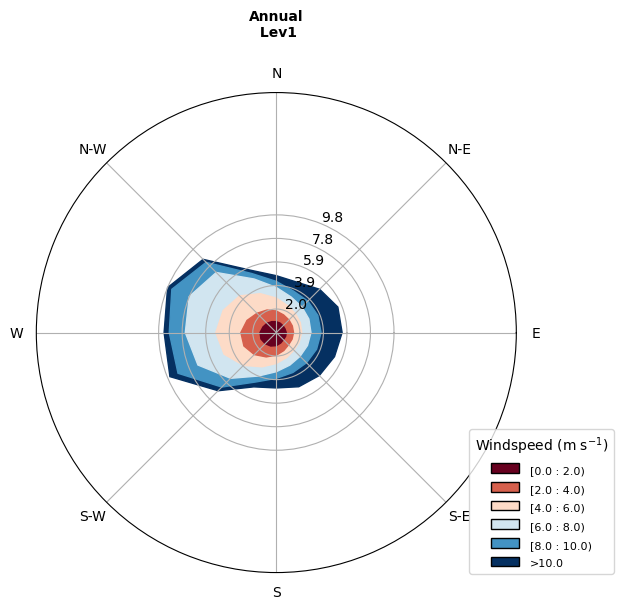

In [11]:
plot_single_windrose(level_ds,  legend=True, title=f"Annual\n Lev1")

<WindroseAxes: title={'center': 'Annual\n Lev1'}>

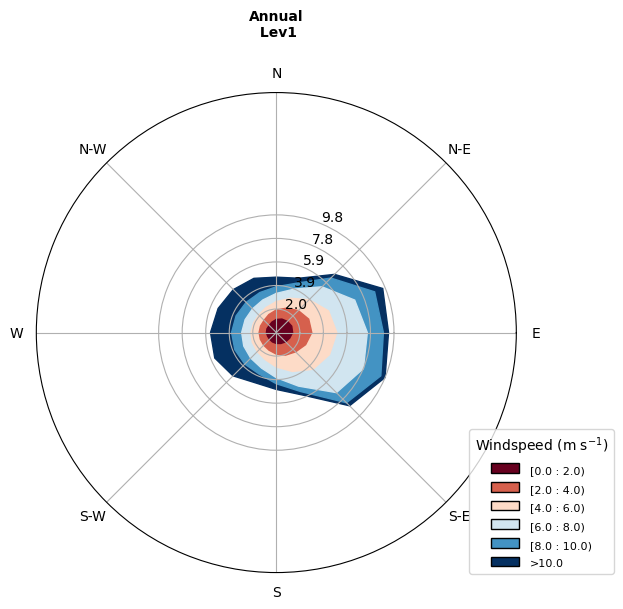

In [12]:
plot_single_windrose(level_ds,  legend=True, title=f"Annual\n Lev1", alternative_direction=True)

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

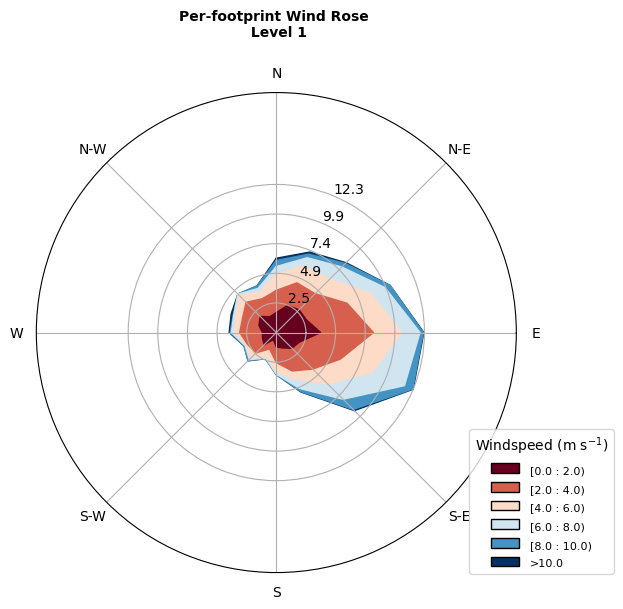

In [ ]:
plot_single_windrose(data.met.sel(lat=25, lon=25, levels=1),  legend=True, title=f"Per-footprint Wind Rose \n Level 1")